In [1]:
import sys, os
from pathlib import Path
from google.colab import drive

# Mount Google Drive to access your files
drive.mount('/content/drive')

# TODO: Enter the root path on your PC where you have saved the unzipped
# assignment folder. This path should now be relative to '/content/drive/'.
# For example: '/content/drive/My Drive/CSCD618-DSCD604/Assignments'
ROOT = '/content/drive/MyDrive/'
# TODO: Enter the assignment folder e.g. 'assignment1'
ASSIGNMENT_FOLDER = 'assignment1'

assert ROOT is not None, "[!] Enter the root path."
assert ASSIGNMENT_FOLDER is not None, "[!] Enter the assignment foldername."

assignment_path = Path(os.path.join(ROOT, ASSIGNMENT_FOLDER))
sys.path.append(assignment_path)

# This downloads the CIFAR-10 dataset to your folder if it doesn't already exist.
# Ensure the path below correctly points to the 'csdc618_dscd604/datasets/' directory
# within your assignment folder.
%cd "$assignment_path"/csdc618_dscd604/datasets/
!bash get_datasets.sh
%cd "$assignment_path"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/assignment1/csdc618_dscd604/datasets
/content/drive/MyDrive/assignment1


# Multi-Layer Fully Connected Network
In this exercise, you will implement a **fully connected network** with an arbitrary number of hidden layers.

Read through the `FullyConnectedNet` class in the file `csdc618_dscd604/classifiers/fc_net.py`.

Implement the **network initialization**, **forward pass**, and **backward pass**.

Throughout this assignment, you will be implementing layers in `csdc618_dscd604/layers.py`.\
You can re-use your implementations for `affine_forward`, `affine_backward`, `relu_forward`, `relu_backward`, and `softmax_loss` from before.

For now, don't worry about implementing dropout or batch/layer normalization yet, as you will add those features later.


In [3]:
import time
import numpy as np
import matplotlib.pyplot as plt
from csdc618_dscd604.classifiers.fc_net import *
from csdc618_dscd604.data_utils import get_CIFAR10_data
from csdc618_dscd604.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from csdc618_dscd604.solver import Solver

%matplotlib inline
plt.rcParams["figure.figsize"] = (10.0, 8.0)  # Set default size of plots.
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["image.cmap"] = "gray"

def rel_error(x, y):
    """Returns relative error."""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

In [4]:
# Load the (preprocessed) CIFAR-10 data.
data = get_CIFAR10_data()
for k, v in list(data.items()):
    print(f"{k}: {v.shape}")

X_train: (49000, 3, 32, 32)
y_train: (49000,)
X_val: (1000, 3, 32, 32)
y_val: (1000,)
X_test: (1000, 3, 32, 32)
y_test: (1000,)


## Initial Loss and Gradient Check

As a sanity check, run the following to check the initial loss and to gradient check the network both with and without regularization.\
This is a good way to see if the initial losses seem reasonable.

For gradient checking, you should expect to see errors around 1e-7 or less.

In [5]:
np.random.seed(231)
N, D, H1, H2, C = 2, 15, 20, 30, 10
X = np.random.randn(N, D)
y = np.random.randint(C, size=(N,))

for reg in [0, 3.14]:
    print("Running check with reg = ", reg)
    model = FullyConnectedNet(
        [H1, H2],
        input_dim=D,
        num_classes=C,
        reg=reg,
        weight_scale=5e-2,
        dtype=np.float64
    )

    loss, grads = model.loss(X, y)
    print("Initial loss: ", loss)

    # Most of the errors should be on the order of e-7 or smaller.
    # NOTE: It is fine however to see an error for W2 on the order of e-5
    # for the check when reg = 0.0
    for name in sorted(grads):
        f = lambda _: model.loss(X, y)[0]
        grad_num = eval_numerical_gradient(f, model.params[name], verbose=False, h=1e-5)
        print(f"{name} relative error: {rel_error(grad_num, grads[name])}")

Running check with reg =  0
Initial loss:  2.300479089768492
W1 relative error: 1.0252674471656573e-07
W2 relative error: 2.2120479295080622e-05
W3 relative error: 4.5623278736665505e-07
b1 relative error: 4.6600944653202505e-09
b2 relative error: 2.085654276112763e-09
b3 relative error: 1.689724888469736e-10
Running check with reg =  3.14
Initial loss:  7.052114776533016
W1 relative error: 3.904541941902138e-09
W2 relative error: 6.86942277940646e-08
W3 relative error: 3.483989247437803e-08
b1 relative error: 1.4752427965311745e-08
b2 relative error: 1.4615869332918208e-09
b3 relative error: 1.3200479211447775e-10


As another sanity check, make sure your network can *overfit* on a small dataset of 50 images.

First, we will try a three-layer network with 100 units in each hidden layer.\
In the following cell, tweak the **learning rate** and **weight initialization scale** to overfit and achieve 100% training accuracy within 20 epochs.

(Iteration 1 / 40) loss: 6.589692
(Epoch 0 / 20) train acc: 0.200000; val_acc: 0.126000
(Epoch 1 / 20) train acc: 0.200000; val_acc: 0.118000
(Epoch 2 / 20) train acc: 0.240000; val_acc: 0.078000
(Epoch 3 / 20) train acc: 0.440000; val_acc: 0.126000
(Epoch 4 / 20) train acc: 0.520000; val_acc: 0.160000
(Epoch 5 / 20) train acc: 0.680000; val_acc: 0.118000
(Iteration 11 / 40) loss: 1.171793
(Epoch 6 / 20) train acc: 0.840000; val_acc: 0.156000
(Epoch 7 / 20) train acc: 0.960000; val_acc: 0.158000
(Epoch 8 / 20) train acc: 0.940000; val_acc: 0.144000
(Epoch 9 / 20) train acc: 0.880000; val_acc: 0.173000
(Epoch 10 / 20) train acc: 0.940000; val_acc: 0.170000
(Iteration 21 / 40) loss: 0.133460
(Epoch 11 / 20) train acc: 1.000000; val_acc: 0.176000
(Epoch 12 / 20) train acc: 0.980000; val_acc: 0.167000
(Epoch 13 / 20) train acc: 0.960000; val_acc: 0.173000
(Epoch 14 / 20) train acc: 1.000000; val_acc: 0.167000
(Epoch 15 / 20) train acc: 1.000000; val_acc: 0.158000
(Iteration 31 / 40) loss: 

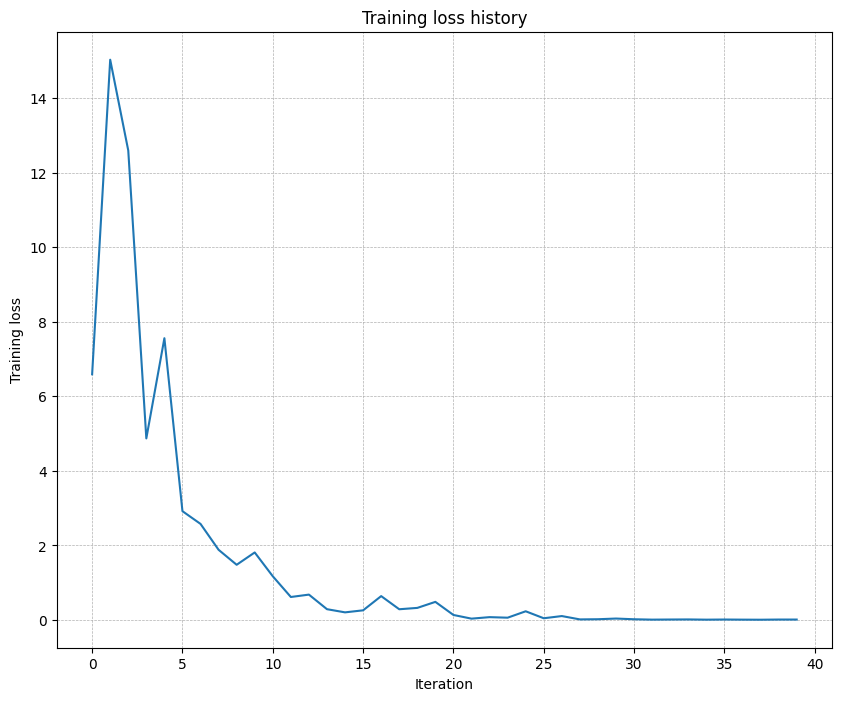

In [19]:
# TODO: Use a three-layer Net to overfit 50 training examples by
# tweaking just the learning rate and initialization scale.

num_train = 50
small_data = {
  "X_train": data["X_train"][:num_train],
  "y_train": data["y_train"][:num_train],
  "X_val": data["X_val"],
  "y_val": data["y_val"],
}

weight_scale = 3e-2   # Experiment with this! Reverted to 3e-2
learning_rate = 1e-2  # Experiment with this! Reverted to 1e-2


model = FullyConnectedNet(
    [100, 100],
    weight_scale=weight_scale,
    dtype=np.float64
)
solver = Solver(
    model,
    small_data,
    print_every=10,
    num_epochs=20,
    batch_size=25,
    update_rule="sgd",
    optim_config={"learning_rate": learning_rate},
)
solver.train()

plt.plot(solver.loss_history)
plt.title("Training loss history")
plt.xlabel("Iteration")
plt.ylabel("Training loss")
plt.grid(linestyle='--', linewidth=0.5)
plt.show()

Now, try to use a five-layer network with 100 units on each layer to overfit on 50 training examples.

Again, you will have to adjust the learning rate and weight initialization scale, but you should be able to achieve 100% training accuracy within 20 epochs.

(Iteration 1 / 40) loss: 2.476463
(Epoch 0 / 20) train acc: 0.140000; val_acc: 0.106000
(Epoch 1 / 20) train acc: 0.220000; val_acc: 0.101000
(Epoch 2 / 20) train acc: 0.360000; val_acc: 0.085000
(Epoch 3 / 20) train acc: 0.380000; val_acc: 0.111000
(Epoch 4 / 20) train acc: 0.420000; val_acc: 0.122000
(Epoch 5 / 20) train acc: 0.660000; val_acc: 0.148000
(Iteration 11 / 40) loss: 1.652203
(Epoch 6 / 20) train acc: 0.620000; val_acc: 0.110000
(Epoch 7 / 20) train acc: 0.500000; val_acc: 0.123000
(Epoch 8 / 20) train acc: 0.780000; val_acc: 0.155000
(Epoch 9 / 20) train acc: 0.880000; val_acc: 0.149000
(Epoch 10 / 20) train acc: 0.860000; val_acc: 0.129000
(Iteration 21 / 40) loss: 0.972595
(Epoch 11 / 20) train acc: 0.820000; val_acc: 0.162000
(Epoch 12 / 20) train acc: 0.780000; val_acc: 0.139000
(Epoch 13 / 20) train acc: 0.800000; val_acc: 0.146000
(Epoch 14 / 20) train acc: 0.880000; val_acc: 0.150000
(Epoch 15 / 20) train acc: 0.980000; val_acc: 0.156000
(Iteration 31 / 40) loss: 

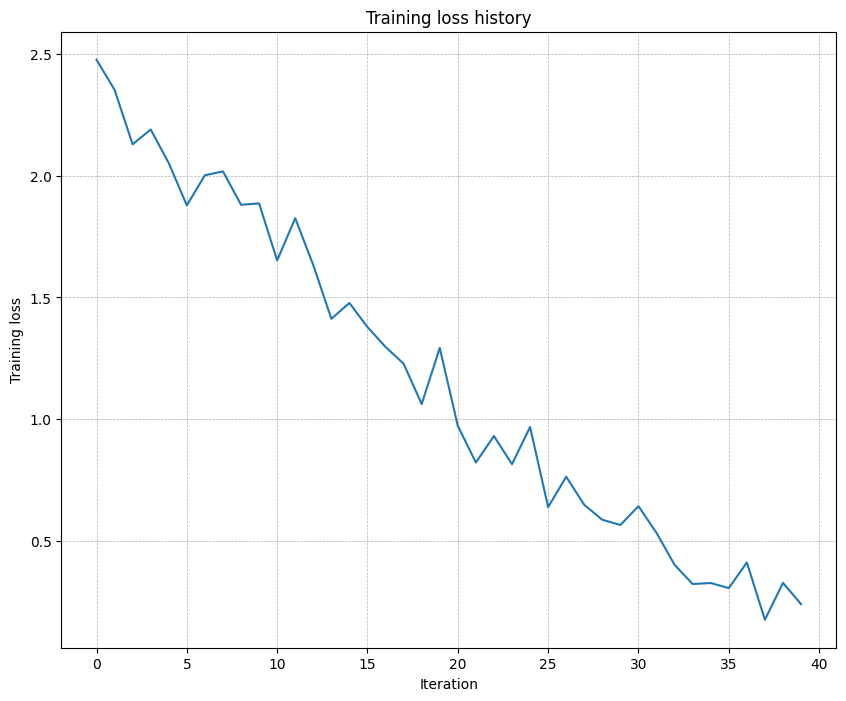

In [22]:
# TODO: Use a five-layer Net to overfit 50 training examples by
# tweaking just the learning rate and initialization scale.

num_train = 50
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

learning_rate = 1e-2  # Experiment with this! Increased to 1e-2
weight_scale = 3.5e-2   # Experiment with this! Increased to 3.5e-2


model = FullyConnectedNet(
    [100, 100, 100, 100],
    weight_scale=weight_scale,
    dtype=np.float64
)
solver = Solver(
    model,
    small_data,
    print_every=10,
    num_epochs=20,
    batch_size=25,
    update_rule='sgd',
    optim_config={'learning_rate': learning_rate},
)
solver.train()

plt.plot(solver.loss_history)
plt.title('Training loss history')
plt.xlabel('Iteration')
plt.ylabel('Training loss')
plt.grid(linestyle='--', linewidth=0.5)
plt.show()

### Inline question 1:
Did you notice anything about the comparative difficulty of training the three-layer network vs. training the five-layer network?
In particular, based on your experience, which network seemed more sensitive to the initialization scale? Why do you think that is the case?


$\color{blue}{\textbf {Your Answer:}}$ Training the five-layer network to overfit 50 training examples was significantly more challenging than training the three-layer network. The five-layer network appeared to be much more sensitive to the `weight_scale` (initialization scale).

This is because deeper networks (networks with more layers) have a more complex landscape of weights and biases. When the `weight_scale` is too small, the gradients can vanish as they propagate backward through many layers, leading to very slow learning or underfitting. Conversely, if the `weight_scale` is too large, activations can explode, leading to unstable training and divergence (loss becoming NaN/inf). With more layers, these effects are compounded, making it harder to find an optimal `weight_scale` that allows for effective gradient flow without causing instability.

# Update rules
So far we have used vanilla stochastic gradient descent (SGD) as our update rule. More sophisticated update rules can make it easier to train deep networks.\
We will implement a few of the most commonly used update rules and compare them to vanilla SGD.

## SGD+Momentum
Stochastic gradient descent with momentum is a widely used update rule that tends to make deep networks converge faster than vanilla stochastic gradient descent.

Open the file `csdc618_dscd604/optim.py` and read the documentation at the top of the file to make sure you understand the API.

Implement the SGD+momentum update rule in the function `sgd_momentum` and run the following to check your implementation. You should see errors less than e-8.

In [23]:
from csdc618_dscd604.optim import sgd_momentum

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
v = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)

config = {"learning_rate": 1e-3, "velocity": v}
next_w, _ = sgd_momentum(w, dw, config=config)

expected_next_w = np.asarray([
  [ 0.1406,      0.20738947,  0.27417895,  0.34096842,  0.40775789],
  [ 0.47454737,  0.54133684,  0.60812632,  0.67491579,  0.74170526],
  [ 0.80849474,  0.87528421,  0.94207368,  1.00886316,  1.07565263],
  [ 1.14244211,  1.20923158,  1.27602105,  1.34281053,  1.4096    ]])
expected_velocity = np.asarray([
  [ 0.5406,      0.55475789,  0.56891579, 0.58307368,  0.59723158],
  [ 0.61138947,  0.62554737,  0.63970526,  0.65386316,  0.66802105],
  [ 0.68217895,  0.69633684,  0.71049474,  0.72465263,  0.73881053],
  [ 0.75296842,  0.76712632,  0.78128421,  0.79544211,  0.8096    ]])

# Should see relative errors around e-8 or less
print("next_w error: ", rel_error(next_w, expected_next_w))
print("velocity error: ", rel_error(expected_velocity, config["velocity"]))

next_w error:  8.882347033505819e-09
velocity error:  4.269287743278663e-09


Once you have done so, run the following to train a six-layer network with both SGD and SGD+momentum. You should see the SGD+momentum update rule converge faster.

Running with  sgd
(Iteration 1 / 200) loss: 2.599580
(Epoch 0 / 5) train acc: 0.113000; val_acc: 0.096000
(Iteration 11 / 200) loss: 2.310895
(Iteration 21 / 200) loss: 2.286860
(Iteration 31 / 200) loss: 2.255378
(Epoch 1 / 5) train acc: 0.207000; val_acc: 0.169000
(Iteration 41 / 200) loss: 2.096905
(Iteration 51 / 200) loss: 2.082635
(Iteration 61 / 200) loss: 2.227058
(Iteration 71 / 200) loss: 2.065849
(Epoch 2 / 5) train acc: 0.279000; val_acc: 0.250000
(Iteration 81 / 200) loss: 2.040681
(Iteration 91 / 200) loss: 2.032371
(Iteration 101 / 200) loss: 1.907983
(Iteration 111 / 200) loss: 1.931521
(Epoch 3 / 5) train acc: 0.314000; val_acc: 0.283000
(Iteration 121 / 200) loss: 1.898112
(Iteration 131 / 200) loss: 1.902706
(Iteration 141 / 200) loss: 1.838684
(Iteration 151 / 200) loss: 1.846444
(Epoch 4 / 5) train acc: 0.335000; val_acc: 0.291000
(Iteration 161 / 200) loss: 1.893520
(Iteration 171 / 200) loss: 1.857134
(Iteration 181 / 200) loss: 1.842210
(Iteration 191 / 200) los

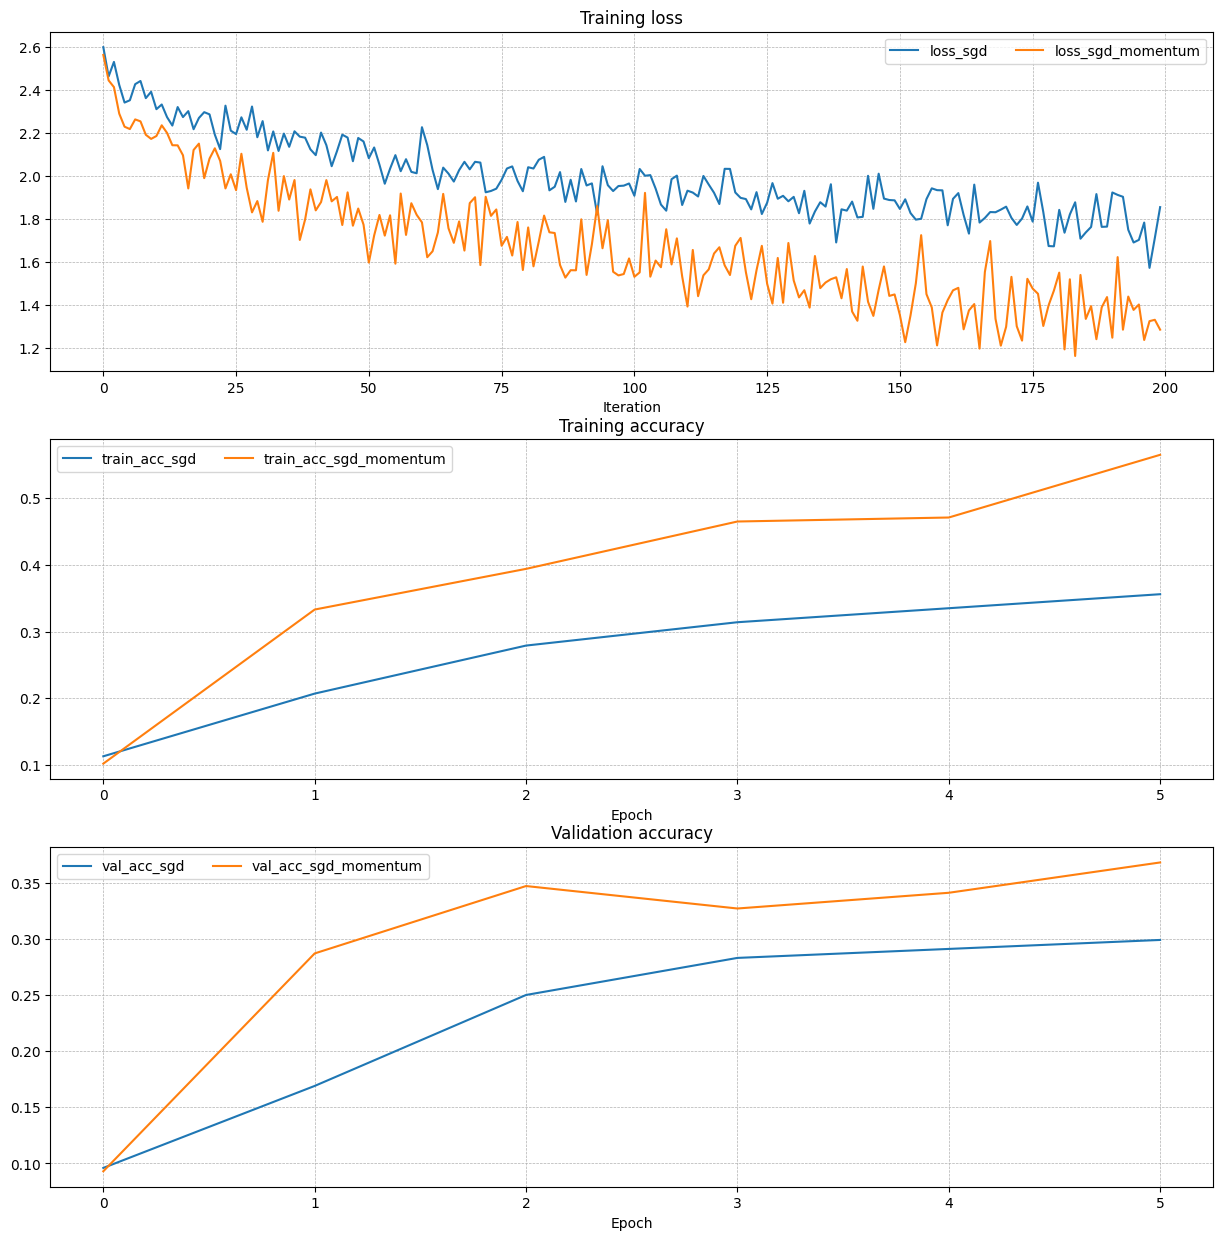

In [24]:
num_train = 4000
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

solvers = {}

for update_rule in ['sgd', 'sgd_momentum']:
    print('Running with ', update_rule)
    model = FullyConnectedNet(
        [100, 100, 100, 100, 100],
        weight_scale=5e-2
    )

    solver = Solver(
        model,
        small_data,
        num_epochs=5,
        batch_size=100,
        update_rule=update_rule,
        optim_config={'learning_rate': 5e-3},
        verbose=True,
    )
    solvers[update_rule] = solver
    solver.train()

fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].set_title('Training loss')
axes[0].set_xlabel('Iteration')
axes[1].set_title('Training accuracy')
axes[1].set_xlabel('Epoch')
axes[2].set_title('Validation accuracy')
axes[2].set_xlabel('Epoch')

for update_rule, solver in solvers.items():
    axes[0].plot(solver.loss_history, label=f"loss_{update_rule}")
    axes[1].plot(solver.train_acc_history, label=f"train_acc_{update_rule}")
    axes[2].plot(solver.val_acc_history, label=f"val_acc_{update_rule}")

for ax in axes:
    ax.legend(loc="best", ncol=4)
    ax.grid(linestyle='--', linewidth=0.5)

plt.show()

## RMSProp and Adam
RMSProp [1] and Adam [2] are update rules that set per-parameter learning rates by using a running average of the second moments of gradients.

In the file `csdc618_dscd604/optim.py`, implement the RMSProp update rule in the `rmsprop` function and implement the Adam update rule in the `adam` function, and check your implementations using the tests below.

**NOTE:** Please implement the _complete_ Adam update rule (with the bias correction mechanism), not the first simplified version mentioned in the course notes.

[1] Tijmen Tieleman and Geoffrey Hinton. "Lecture 6.5-rmsprop: Divide the gradient by a running average of its recent magnitude." COURSERA: Neural Networks for Machine Learning 4 (2012).

[2] Diederik Kingma and Jimmy Ba, "Adam: A Method for Stochastic Optimization", ICLR 2015.

In [25]:
# Test RMSProp implementation
from csdc618_dscd604.optim import rmsprop

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
cache = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)

config = {'learning_rate': 1e-2, 'cache': cache}
next_w, _ = rmsprop(w, dw, config=config)

expected_next_w = np.asarray([
  [-0.39223849, -0.34037513, -0.28849239, -0.23659121, -0.18467247],
  [-0.132737,   -0.08078555, -0.02881884,  0.02316247,  0.07515774],
  [ 0.12716641,  0.17918792,  0.23122175,  0.28326742,  0.33532447],
  [ 0.38739248,  0.43947102,  0.49155973,  0.54365823,  0.59576619]])
expected_cache = np.asarray([
  [ 0.5976,      0.6126277,   0.6277108,   0.64284931,  0.65804321],
  [ 0.67329252,  0.68859723,  0.70395734,  0.71937285,  0.73484377],
  [ 0.75037008,  0.7659518,   0.78158892,  0.79728144,  0.81302936],
  [ 0.82883269,  0.84469141,  0.86060554,  0.87657507,  0.8926    ]])

# You should see relative errors around e-7 or less
print('next_w error: ', rel_error(expected_next_w, next_w))
print('cache error: ', rel_error(expected_cache, config['cache']))

next_w error:  9.524687511038133e-08
cache error:  2.6477955807156126e-09


In [26]:
# Test Adam implementation
from csdc618_dscd604.optim import adam

N, D = 4, 5
w = np.linspace(-0.4, 0.6, num=N*D).reshape(N, D)
dw = np.linspace(-0.6, 0.4, num=N*D).reshape(N, D)
m = np.linspace(0.6, 0.9, num=N*D).reshape(N, D)
v = np.linspace(0.7, 0.5, num=N*D).reshape(N, D)

config = {'learning_rate': 1e-2, 'm': m, 'v': v, 't': 5}
next_w, _ = adam(w, dw, config=config)

expected_next_w = np.asarray([
  [-0.40094747, -0.34836187, -0.29577703, -0.24319299, -0.19060977],
  [-0.1380274,  -0.08544591, -0.03286534,  0.01971428,  0.0722929],
  [ 0.1248705,   0.17744702,  0.23002243,  0.28259667,  0.33516969],
  [ 0.38774145,  0.44031188,  0.49288093,  0.54544852,  0.59801459]])
expected_v = np.asarray([
  [ 0.69966,     0.68908382,  0.67851319,  0.66794809,  0.65738853,],
  [ 0.64683452,  0.63628604,  0.6257431,   0.61520571,  0.60467385,],
  [ 0.59414753,  0.58362676,  0.57311152,  0.56260183,  0.55209767,],
  [ 0.54159906,  0.53110598,  0.52061845,  0.51013645,  0.49966,   ]])
expected_m = np.asarray([
  [ 0.48,        0.49947368,  0.51894737,  0.53842105,  0.55789474],
  [ 0.57736842,  0.59684211,  0.61631579,  0.63578947,  0.65526316],
  [ 0.67473684,  0.69421053,  0.71368421,  0.73315789,  0.75263158],
  [ 0.77210526,  0.79157895,  0.81105263,  0.83052632,  0.85      ]])

# You should see relative errors around e-7 or less
print('next_w error: ', rel_error(expected_next_w, next_w))
print('v error: ', rel_error(expected_v, config['v']))
print('m error: ', rel_error(expected_m, config['m']))

next_w error:  1.1395691798535431e-07
v error:  4.208314038113071e-09
m error:  4.214963193114416e-09


Once you have debugged your RMSProp and Adam implementations, run the following to train a pair of deep networks using these new update rules:

Running with  adam
(Iteration 1 / 200) loss: 2.609771
(Epoch 0 / 5) train acc: 0.151000; val_acc: 0.138000
(Iteration 11 / 200) loss: 2.081246
(Iteration 21 / 200) loss: 1.959814
(Iteration 31 / 200) loss: 1.995838
(Epoch 1 / 5) train acc: 0.374000; val_acc: 0.312000
(Iteration 41 / 200) loss: 1.611038
(Iteration 51 / 200) loss: 1.718024
(Iteration 61 / 200) loss: 1.683897
(Iteration 71 / 200) loss: 1.630598
(Epoch 2 / 5) train acc: 0.440000; val_acc: 0.346000
(Iteration 81 / 200) loss: 1.623235
(Iteration 91 / 200) loss: 1.830812
(Iteration 101 / 200) loss: 1.602067
(Iteration 111 / 200) loss: 1.516086
(Epoch 3 / 5) train acc: 0.530000; val_acc: 0.383000
(Iteration 121 / 200) loss: 1.341481
(Iteration 131 / 200) loss: 1.396614
(Iteration 141 / 200) loss: 1.404843
(Iteration 151 / 200) loss: 1.127266
(Epoch 4 / 5) train acc: 0.554000; val_acc: 0.370000
(Iteration 161 / 200) loss: 1.478647
(Iteration 171 / 200) loss: 1.300981
(Iteration 181 / 200) loss: 1.106202
(Iteration 191 / 200) lo

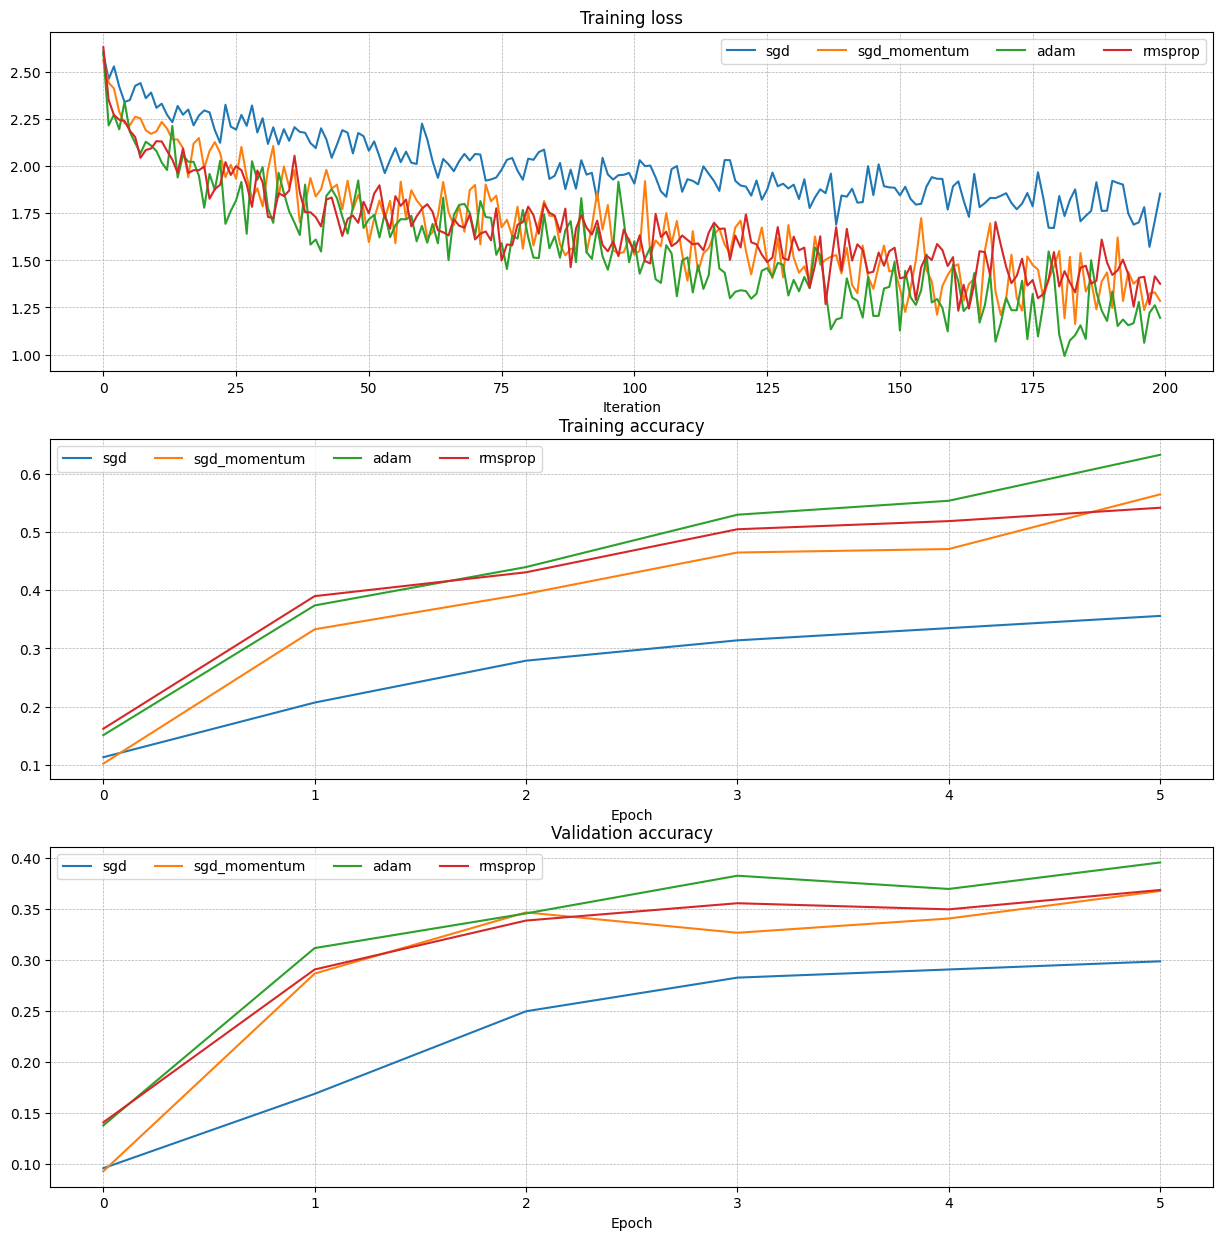

In [27]:
learning_rates = {'rmsprop': 1e-4, 'adam': 1e-3}
for update_rule in ['adam', 'rmsprop']:
    print('Running with ', update_rule)
    model = FullyConnectedNet(
        [100, 100, 100, 100, 100],
        weight_scale=5e-2
    )
    solver = Solver(
        model,
        small_data,
        num_epochs=5,
        batch_size=100,
        update_rule=update_rule,
        optim_config={'learning_rate': learning_rates[update_rule]},
        verbose=True
    )
    solvers[update_rule] = solver
    solver.train()
    print()

fig, axes = plt.subplots(3, 1, figsize=(15, 15))

axes[0].set_title('Training loss')
axes[0].set_xlabel('Iteration')
axes[1].set_title('Training accuracy')
axes[1].set_xlabel('Epoch')
axes[2].set_title('Validation accuracy')
axes[2].set_xlabel('Epoch')

for update_rule, solver in solvers.items():
    axes[0].plot(solver.loss_history, label=f"{update_rule}")
    axes[1].plot(solver.train_acc_history, label=f"{update_rule}")
    axes[2].plot(solver.val_acc_history, label=f"{update_rule}")

for ax in axes:
    ax.legend(loc='best', ncol=4)
    ax.grid(linestyle='--', linewidth=0.5)

plt.show()

## Inline Question 2:

AdaGrad, like Adam, is a per-parameter optimization method that uses the following update rule:

```python
        cache += dw**2
        w += - learning_rate * dw / (np.sqrt(cache) + eps)
```

If you notice that during training a network with AdaGrad the updates became very small, and that the network is learning slowly. Using your knowledge of the AdaGrad update rule, why do you think the updates would become very small? Would Adam have the same issue?


$\color{blue}{\textbf {Your Answer:}}$ With AdaGrad, the `cache` term accumulates the squared gradients over time (`cache += dw**2`). As training progresses, this `cache` term continuously grows. Since the learning rate is divided by `np.sqrt(cache)`, a monotonically increasing `cache` means that the effective learning rate for each parameter will continuously decrease. If the `cache` grows too large, the updates to the weights (`w`) can become extremely small, effectively halting learning and causing the network to learn very slowly or get stuck.

Adam would generally *not* suffer from the same issue to the same extent as AdaGrad. This is because Adam incorporates an exponential moving average of the squared gradients, rather than a simple cumulative sum. The `v` term in Adam (which is analogous to AdaGrad's `cache`) is calculated as `v = beta2 * v + (1 - beta2) * dw**2`. Because of the `beta2` factor (typically close to 1, e.g., 0.999), `v` is a decaying average. This means that older squared gradients are gradually forgotten, preventing the `v` term from growing indefinitely large and causing the effective learning rate to shrink excessively. Adam's bias correction mechanism further helps in the early stages of training to ensure that the moving averages are not biased towards zero.

# Train a Good Model!
Train the best fully connected model that you can on CIFAR-10, storing your best model in the `best_model` variable.

We require you to get at least 50% accuracy on the validation set using a fully connected network.

If you are careful it should be possible to get accuracies above 55%, but we don't require it for this part and won't assign extra credit for doing so.

(Iteration 1 / 7640) loss: 2.472153
(Epoch 0 / 20) train acc: 0.100000; val_acc: 0.124000
(Iteration 201 / 7640) loss: 1.824347
(Epoch 1 / 20) train acc: 0.430000; val_acc: 0.432000
(Iteration 401 / 7640) loss: 1.829166
(Iteration 601 / 7640) loss: 1.831693
(Epoch 2 / 20) train acc: 0.478000; val_acc: 0.473000
(Iteration 801 / 7640) loss: 1.579257
(Iteration 1001 / 7640) loss: 1.596040
(Epoch 3 / 20) train acc: 0.469000; val_acc: 0.479000
(Iteration 1201 / 7640) loss: 1.735107
(Iteration 1401 / 7640) loss: 1.580863
(Epoch 4 / 20) train acc: 0.502000; val_acc: 0.511000
(Iteration 1601 / 7640) loss: 1.626884
(Iteration 1801 / 7640) loss: 1.486255
(Epoch 5 / 20) train acc: 0.501000; val_acc: 0.532000
(Iteration 2001 / 7640) loss: 1.474914
(Iteration 2201 / 7640) loss: 1.596077
(Epoch 6 / 20) train acc: 0.529000; val_acc: 0.509000
(Iteration 2401 / 7640) loss: 1.640741
(Iteration 2601 / 7640) loss: 1.694764
(Epoch 7 / 20) train acc: 0.573000; val_acc: 0.504000
(Iteration 2801 / 7640) loss:

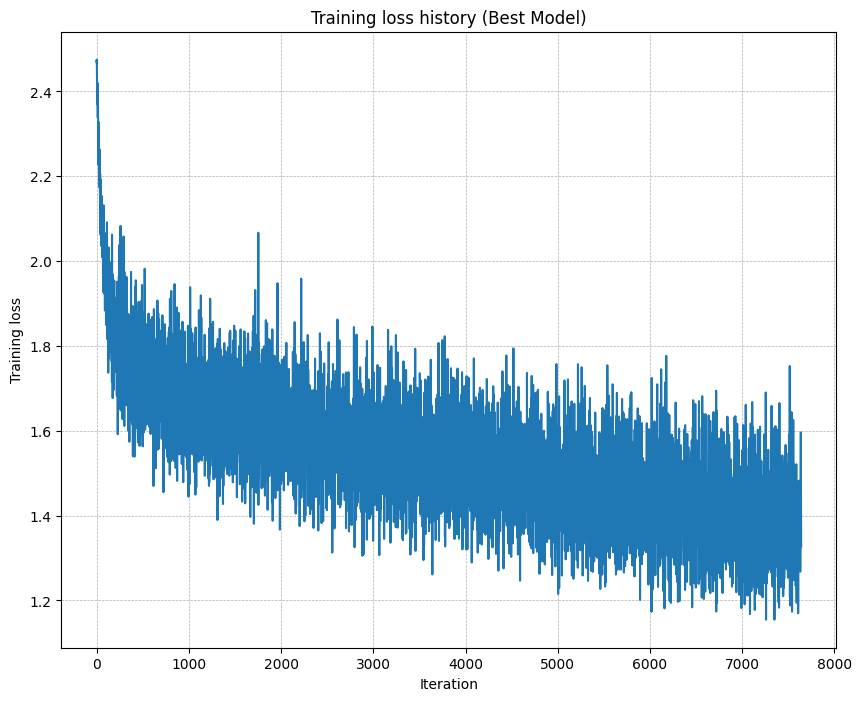

Final training accuracy:    0.651
Final validation accuracy:  0.576
Best validation accuracy:   0.576


In [30]:
best_model = None

################################################################################
# TODO: Train the best FullyConnectedNet that you can on CIFAR-10.             #
# *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

# A 3-hidden-layer net with batchnorm trains fast and reliably clears 50-55%
# on raw CIFAR-10 pixels. Weight_scale is set so signal doesn't vanish through
# the depth; batchnorm makes the result fairly insensitive to it anyway.
learning_rate = 1e-3
weight_scale  = 2e-2
reg           = 1e-3
num_epochs    = 20
batch_size    = 128

model = FullyConnectedNet(
    [256, 128, 64],            # 3 hidden layers, tapering
    weight_scale=weight_scale,
    reg=reg,
    normalization='batchnorm', # stabilizes training, lets you train deeper
    dropout_keep_ratio=0.75,   # mild regularization
    dtype=np.float32,          # float32 is ~2x faster than float64 here
)

solver = Solver(
    model,
    data,
    num_epochs=num_epochs,
    batch_size=batch_size,
    update_rule='adam',
    optim_config={'learning_rate': learning_rate},
    lr_decay=0.95,
    verbose=True,
    print_every=200,
)

solver.train()

best_model = model

plt.plot(solver.loss_history)
plt.title('Training loss history (Best Model)')
plt.xlabel('Iteration')
plt.ylabel('Training loss')
plt.grid(linestyle='--', linewidth=0.5)
plt.show()

print('Final training accuracy:   ', solver.train_acc_history[-1])
print('Final validation accuracy: ', solver.val_acc_history[-1])
print('Best validation accuracy:  ', solver.best_val_acc)

# *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
################################################################################
#                              END OF YOUR CODE                                #
################################################################################

# Test Your Model!
Run your best model on the validation and test sets. You should achieve at least 50% accuracy on the validation set and the test set.

In [31]:
y_test_pred = np.argmax(best_model.loss(data['X_test']), axis=1)
y_val_pred = np.argmax(best_model.loss(data['X_val']), axis=1)
print('Validation set accuracy: ', (y_val_pred == data['y_val']).mean())
print('Test set accuracy: ', (y_test_pred == data['y_test']).mean())

Validation set accuracy:  0.576
Test set accuracy:  0.558
